# Cơ sở lý thuyết: 

Bộ dữ liệu **Forest Cover Type (Covtype)** là bài toán **phân loại đa lớp (7 lớp)** với quy mô lớn (hơn **580.000 dòng**), vì vậy EDA là bước bắt buộc trước khi xây dựng mô hình. Với dữ liệu lớn, nếu bỏ qua EDA, mô hình có thể học lệch theo phân bố dữ liệu, đánh giá sai mức độ khó của từng lớp, và khó giải thích kết quả.

## 1) Đặc trưng dữ liệu

### Nhóm biến liên tục (10 cột đầu)
Các cột như `Elevation`, `Aspect`, `Slope`, các khoảng cách đến thủy văn/đường đi/điểm cháy rừng,... mang thông tin định lượng về địa hình và vị trí tương đối.

### Nhóm biến nhị phân (Binary)
- **4 cột `Wilderness_Area`**: biểu diễn khu vực hoang dã (mã hóa one-hot).
- **40 cột `Soil_Type`**: biểu diễn nhóm đất (mã hóa one-hot).

Các biến binary thường cho tín hiệu phân loại mạnh theo từng vùng sinh thái, nhưng cần thống kê cẩn thận để tránh kết luận trực giác sai.

## 2) Mục tiêu phân tích trong notebook này

1. Khám phá phân bố biến mục tiêu để đánh giá **mất cân bằng lớp**.
2. Phân tích phân phối các biến liên tục, kiểm tra mức độ tách biệt giữa các lớp qua boxplot.
3. Phân tích tương quan giữa các biến liên tục để phát hiện **đa cộng tuyến (multicollinearity)**.
4. Thống kê quan hệ giữa lớp rừng với `Wilderness_Area` và `Soil_Type` để tìm các tổ hợp xuất hiện nổi bật.
5. Xác định sơ bộ đặc trưng có khả năng quan trọng (đặc biệt là **Elevation**) dựa trên tương quan và mức độ tách lớp quan sát được.


In [1]:
# Khởi tạo, cố định seed và tải dữ liệu
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

# Thiết lập giao diện biểu đồ
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Đường dẫn tương đối tới dữ liệu raw
csv_path = r"../../../data/raw/classification/covtype.csv"

# Tải dữ liệu gốc
df = pd.read_csv(csv_path)
print("Đã load dữ liệu từ:", csv_path)
print("Kích thước dữ liệu:", df.shape)

# Xác định cột mục tiêu
if "Cover_Type" in df.columns:
    target_col = "Cover_Type"
elif "target" in df.columns:
    target_col = "target"
else:
    raise ValueError("Không tìm thấy cột mục tiêu. Kỳ vọng 'Cover_Type' hoặc 'target'.")

# Tách danh sách biến để dùng cho các cell sau
continuous_cols = df.columns[:10].tolist()
wilderness_cols = [c for c in df.columns if c.startswith("Wilderness_Area")]
soil_cols = [c for c in df.columns if c.startswith("Soil_Type")]
order = sorted(df[target_col].unique())

print("Cột mục tiêu:", target_col)
print("Số lớp:", df[target_col].nunique())
print("Số biến liên tục:", len(continuous_cols))
print("Số biến Wilderness:", len(wilderness_cols))
print("Số biến Soil:", len(soil_cols))

Đã load dữ liệu từ: ../../../data/raw/classification/covtype.csv
Kích thước dữ liệu: (581012, 55)
Cột mục tiêu: Cover_Type
Số lớp: 7
Số biến liên tục: 10
Số biến Wilderness: 4
Số biến Soil: 40


## Phân tích 0: Thống kê mô tả và kiểm tra giá trị thiếu

Mục tiêu của phần này:
- Cung cấp thống kê mô tả chuẩn học thuật cho nhóm biến liên tục (mean, std, quartiles, min, max).
- Kiểm tra dữ liệu thiếu để làm rõ giả định cho bước tiền xử lý.
- Tạo bảng tóm tắt định lượng trước khi đi vào phân tích trực quan.

In [2]:
# Phân tích 0 - Descriptive statistics + missing values
desc_stats = df[continuous_cols].describe().T
desc_stats["skew"] = df[continuous_cols].skew()
desc_stats = desc_stats[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "skew"]]

missing_summary = df.isnull().sum()
missing_total = int(missing_summary.sum())

print("Tổng số giá trị thiếu trong toàn bộ dataset:", missing_total)
print("\nSố giá trị thiếu theo cột (top 10 nếu có):")
print(missing_summary[missing_summary > 0].sort_values(ascending=False).head(10))

print("\nThống kê mô tả nhóm biến continuous:")
display(desc_stats.round(3))

Tổng số giá trị thiếu trong toàn bộ dataset: 0

Số giá trị thiếu theo cột (top 10 nếu có):
Series([], dtype: int64)

Thống kê mô tả nhóm biến continuous:


,count,mean,std,min,25%,50%,75%,max,skew
Elevation,581012.0,2959.365,279.985,1859.0,2809.0,2996.0,3163.0,3858.0,-0.818
Aspect,581012.0,155.657,111.914,0.0,58.0,127.0,260.0,360.0,0.403
Slope,581012.0,14.104,7.488,0.0,9.0,13.0,18.0,66.0,0.789
Horizontal_Distance_To_Hydrology,581012.0,269.428,212.549,0.0,108.0,218.0,384.0,1397.0,1.140
Vertical_Distance_To_Hydrology,581012.0,46.419,58.295,-173.0,7.0,30.0,69.0,601.0,1.790
Horizontal_Distance_To_Roadways,581012.0,2350.147,1559.255,0.0,1106.0,1997.0,3328.0,7117.0,0.714
Hillshade_9am,581012.0,212.146,26.770,0.0,198.0,218.0,231.0,254.0,-1.181
Hillshade_Noon,581012.0,223.319,19.769,0.0,213.0,226.0,237.0,254.0,-1.063
Hillshade_3pm,581012.0,142.528,38.275,0.0,119.0,143.0,168.0,254.0,-0.277
Horizontal_Distance_To_Fire_Points,581012.0,1980.291,1324.195,0.0,1024.0,1710.0,2550.0,7173.0,1.289


## Diễn giải thống kê mô tả

- Bảng `describe()` giúp xác nhận nhanh thang đo từng biến, mức độ phân tán và các mốc tứ phân vị.
- Cột `skew` hỗ trợ nhận diện biến lệch mạnh để định hướng chọn scaler hoặc biến đổi ở notebook preprocessing.
- Nếu tổng giá trị thiếu bằng 0, ta có thể ghi rõ trong báo cáo rằng không cần bước imputing cho Covtype.

## Phân tích 1: Mất cân bằng lớp mục tiêu

Mục tiêu của phần này:
- Đo mức độ mất cân bằng giữa 7 lớp Cover Type bằng cả trực quan và số liệu.
- Dùng thang log để đảm bảo lớp hiếm vẫn quan sát rõ.
- Tạo cơ sở để lựa chọn metric phù hợp ở giai đoạn mô hình hóa.

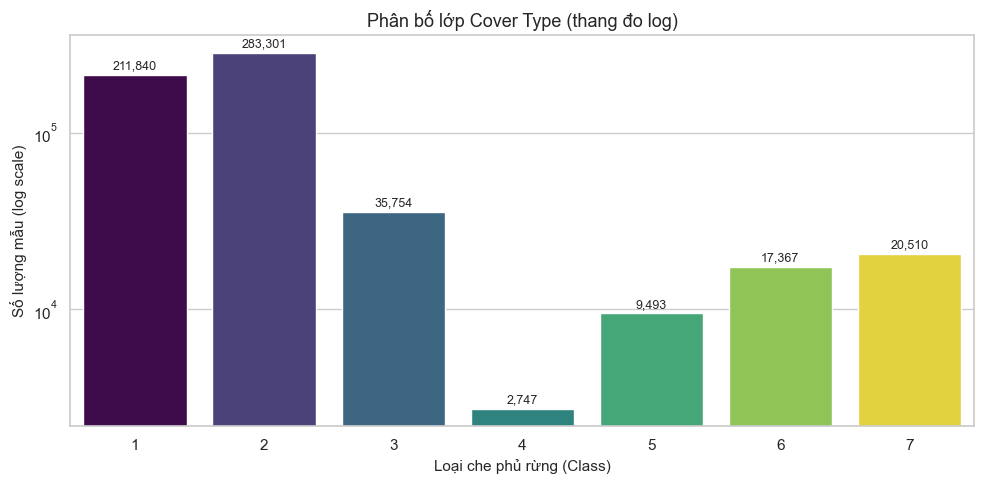

Số mẫu theo từng lớp:
Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64

Tỷ lệ theo từng lớp:
Cover_Type
1    0.3646
2    0.4876
3    0.0615
4    0.0047
5    0.0163
6    0.0299
7    0.0353
Name: count, dtype: float64

Imbalance ratio (max/min): 103.13


In [3]:

#  Mất cân bằng lớp mục tiêu


plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x=target_col, hue=target_col, order=order, palette="viridis")
if ax.legend_ is not None:
    ax.legend_.remove()

ax.set_yscale("log")
ax.set_title("Phân bố lớp Cover Type (thang đo log)")
ax.set_xlabel("Loại che phủ rừng (Class)")
ax.set_ylabel("Số lượng mẫu (log scale)")

for p in ax.patches:
    h = int(p.get_height())
    ax.annotate(
        f"{h:,}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 2),
        textcoords="offset points",
    )

plt.tight_layout()
plt.show()

class_counts = df[target_col].value_counts().sort_index()
class_ratio = (class_counts / class_counts.sum()).round(4)
imbalance_ratio = class_counts.max() / class_counts.min()

print("Số mẫu theo từng lớp:")
print(class_counts)
print("\nTỷ lệ theo từng lớp:")
print(class_ratio)
print(f"\nImbalance ratio (max/min): {imbalance_ratio:.2f}")

## Diễn giải 

Kết quả chính từ output:
- Class 2 lớn nhất: 283,301 mẫu (~48.76%), class 1 đứng thứ hai: 211,840 mẫu (~36.46%).
- Class 4 nhỏ nhất: 2,747 mẫu (~0.47%).
- Imbalance ratio = 103.13, tức lớp lớn nhất gấp hơn 100 lần lớp nhỏ nhất.

Hàm ý:
- Accuracy đơn thuần có nguy cơ đánh giá quá lạc quan.
- Ở bước modeling nên ưu tiên macro-F1, balanced accuracy và recall theo từng lớp.

## Phân tích 2: Phân phối 10 biến liên tục

Mục tiêu của phần này:
- Quan sát hình dạng phân phối (lệch, đa đỉnh, đuôi dài) của 10 biến continuous.
- Nhận diện biến nào có outlier mạnh hoặc phân phối không chuẩn.
- Chuẩn bị cơ sở trực quan cho bước so sánh theo lớp ở phần boxplot.

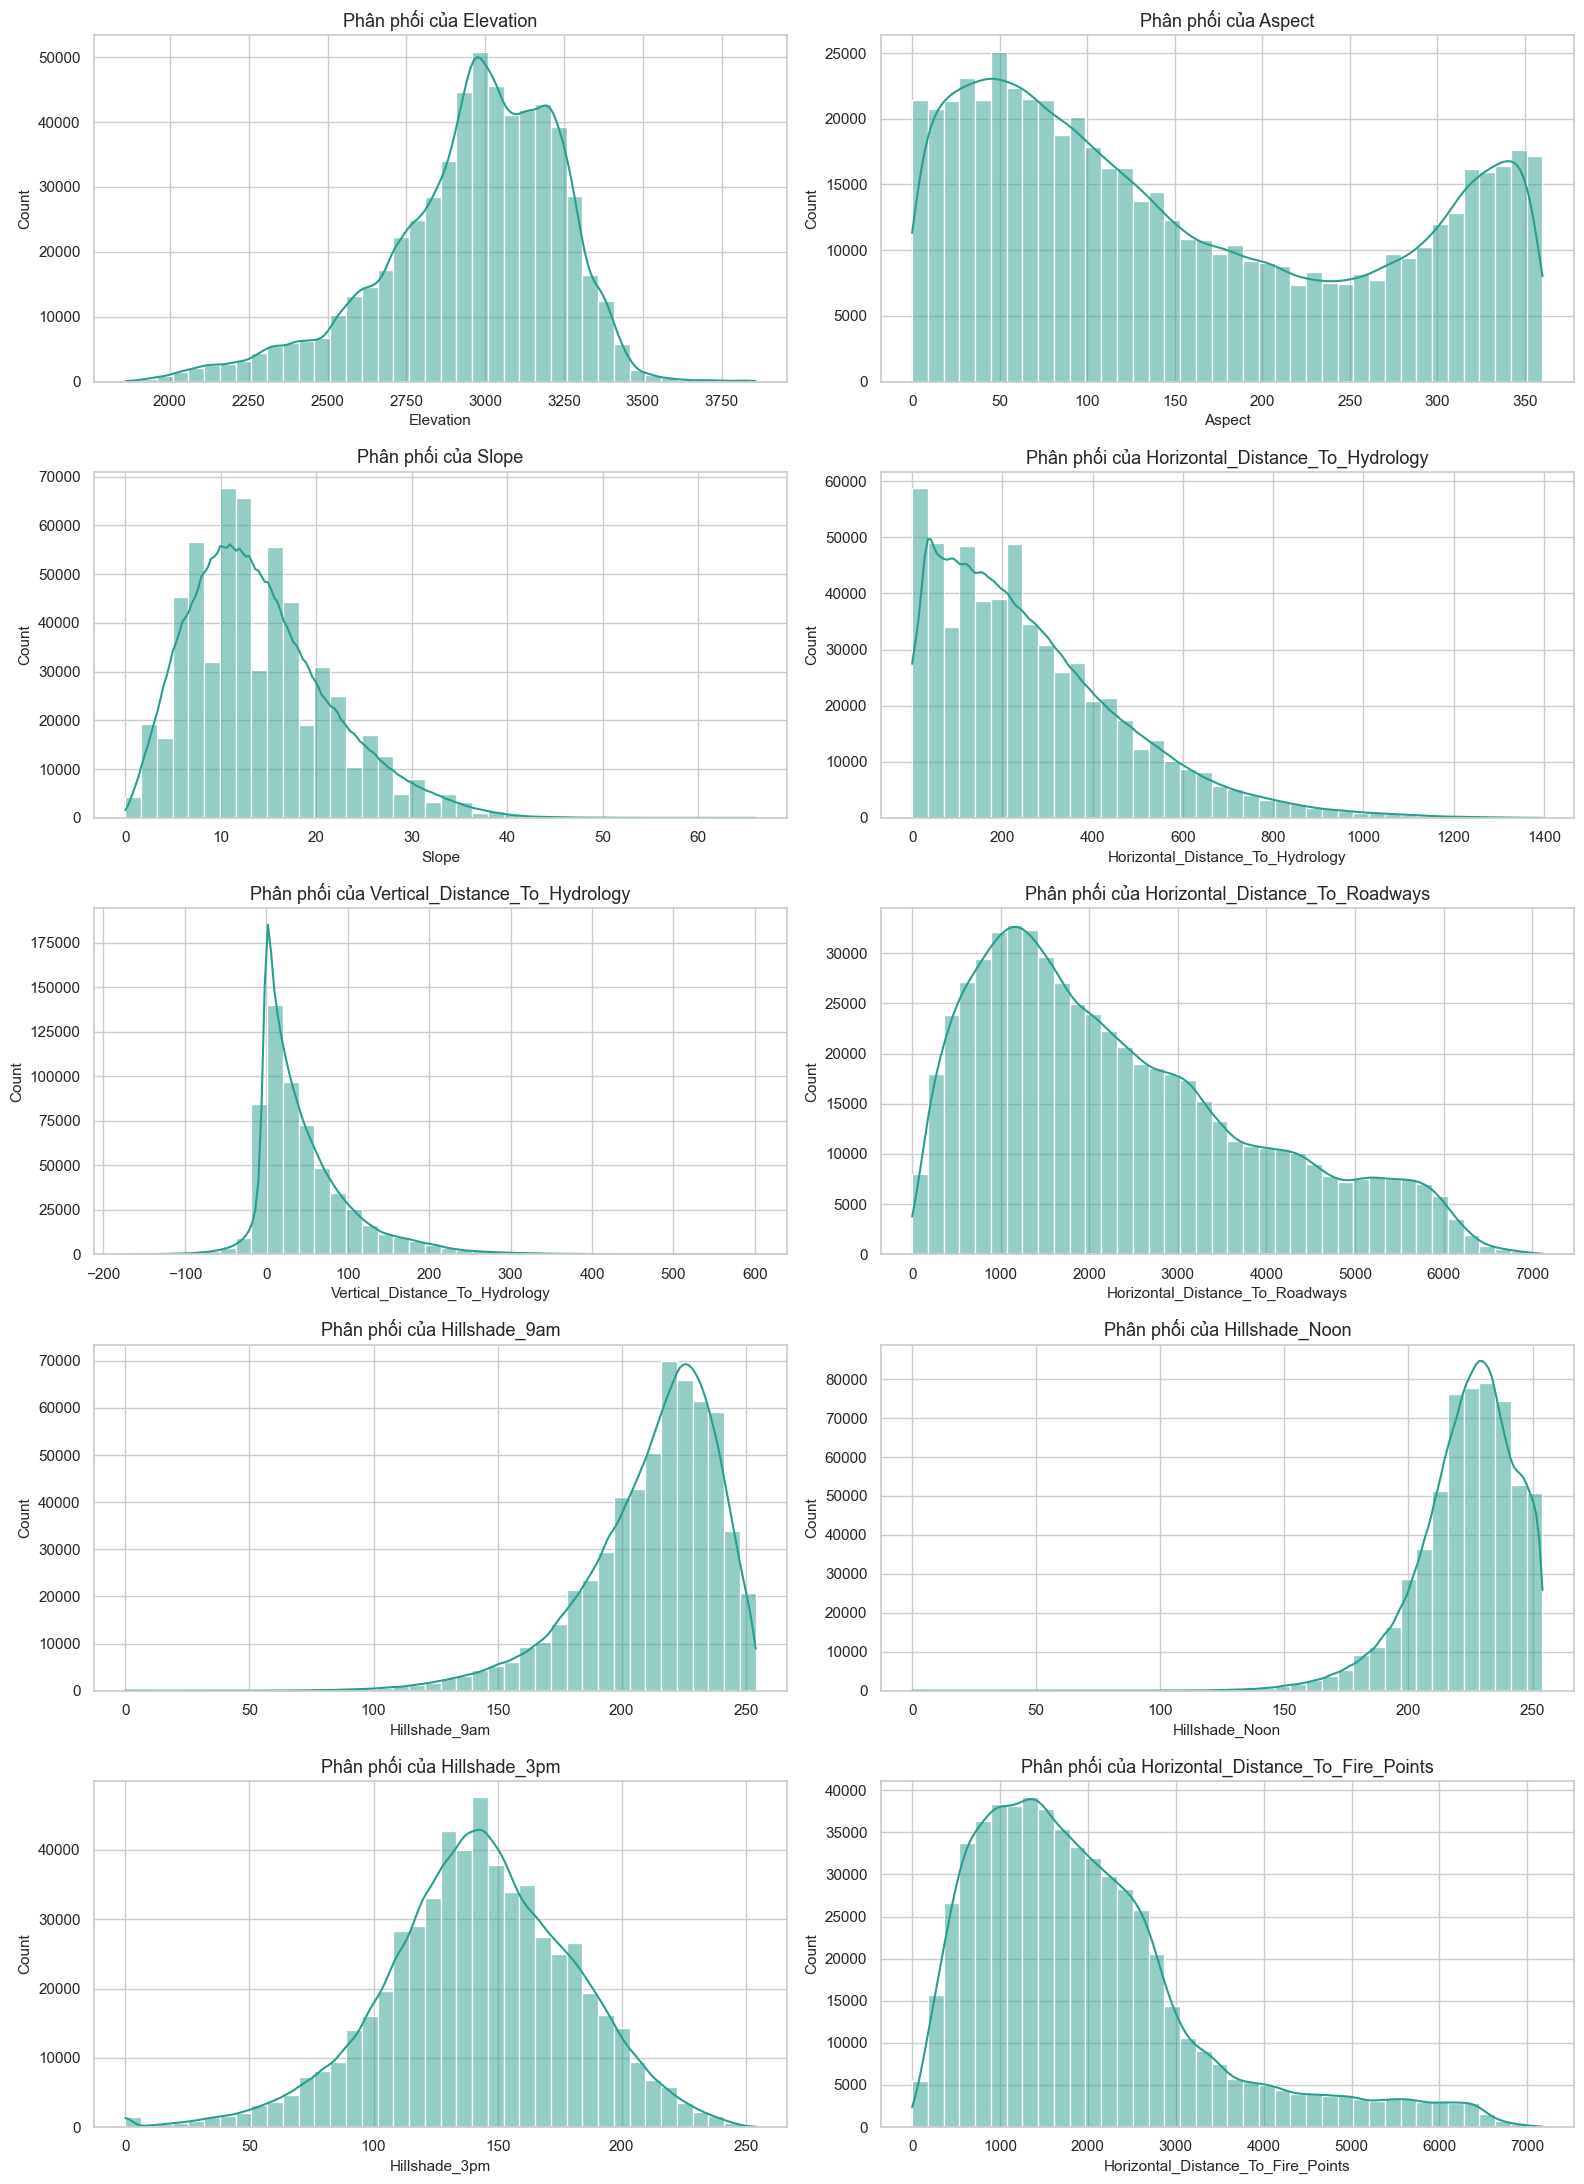

In [4]:

#  Phân phối 10 biến liên tục


fig, axes = plt.subplots(5, 2, figsize=(16, 22))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.histplot(data=df, x=col, kde=True, bins=40, color="#2a9d8f", ax=axes[i])
    axes[i].set_title(f"Phân phối của {col}")

plt.tight_layout()
plt.show()

## Diễn giải 

- Nhiều biến có phân phối lệch phải (right-skew), đặc biệt nhóm khoảng cách; điều này cho thấy có cụm nhỏ các điểm rất xa so với phần lớn quan sát.
- Một số biến hillshade có phân phối tập trung mạnh quanh vùng trung tâm, phản ánh điều kiện chiếu sáng không phân bố đều trên toàn miền địa hình.
- Độ lệch và đuôi dài trong phân phối là tín hiệu rằng các mô hình nhạy phân phối có thể cần chuẩn hóa/biến đổi ở giai đoạn mô hình hóa.

## Phân tích 2B: Phát hiện outlier theo quy tắc IQR

Mục tiêu của phần này:
- Formalize phát hiện outlier theo đúng chuẩn IQR ($1.5\times IQR$).
- Định lượng số lượng và tỉ lệ outlier cho từng biến continuous.
- Tạo căn cứ trực tiếp cho lựa chọn RobustScaler/clip ở notebook preprocessing.

,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_ratio
4,Vertical_Distance_To_Hydrology,7.0,69.0,62.0,-86.0,162.0,31463,0.0542
9,Horizontal_Distance_To_Fire_Points,1024.0,2550.0,1526.0,-1265.0,4839.0,31157,0.0536
6,Hillshade_9am,198.0,231.0,33.0,148.5,280.5,17433,0.0300
7,Hillshade_Noon,213.0,237.0,24.0,177.0,273.0,15672,0.0270
0,Elevation,2809.0,3163.0,354.0,2278.0,3694.0,15569,0.0268
2,Slope,9.0,18.0,9.0,-4.5,31.5,15316,0.0264
3,Horizontal_Distance_To_Hydrology,108.0,384.0,276.0,-306.0,798.0,14557,0.0251
8,Hillshade_3pm,119.0,168.0,49.0,45.5,241.5,7832,0.0135
5,Horizontal_Distance_To_Roadways,1106.0,3328.0,2222.0,-2227.0,6661.0,669,0.0012
1,Aspect,58.0,260.0,202.0,-245.0,563.0,0,0.0000


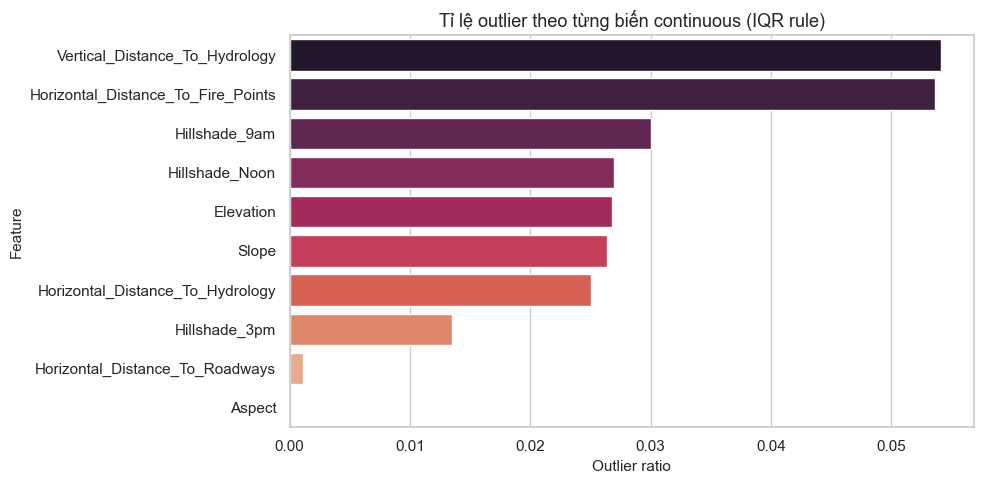

In [5]:
# Phân tích 2B - Outlier detection bằng IQR
outlier_rows = []

for col in continuous_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (df[col] < lower) | (df[col] > upper)
    outlier_count = int(mask.sum())
    outlier_ratio = outlier_count / len(df)

    outlier_rows.append(
        {
            "feature": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count": outlier_count,
            "outlier_ratio": outlier_ratio,
        }
    )

outlier_df = pd.DataFrame(outlier_rows).sort_values("outlier_ratio", ascending=False)
display(outlier_df.round(4))

plt.figure(figsize=(10, 5))
sns.barplot(
    data=outlier_df,
    x="outlier_ratio",
    y="feature",
    hue="feature",
    palette="rocket",
    legend=False,
)
plt.title("Tỉ lệ outlier theo từng biến continuous (IQR rule)")
plt.xlabel("Outlier ratio")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Diễn giải outlier

- Bảng IQR cho biết rõ biến nào chứa nhiều điểm cực trị nhất thay vì chỉ nhìn định tính qua boxplot.
- Các biến khoảng cách thường có tỉ lệ outlier cao hơn nhóm hillshade, phù hợp với hiện tượng right-skew trong histogram.
- Kết quả này là lý do trực tiếp để ưu tiên `RobustScaler` và cân nhắc clipping cho nhóm continuous trong preprocessing.

## Phân tích 3: So sánh phân phối theo lớp (Boxplot)

Mục tiêu của phần này:
- So sánh sự khác biệt trung vị và độ phân tán giữa các lớp rừng.
- Đánh giá mức độ chồng lấn giữa lớp để dự báo nguy cơ nhầm lẫn.
- Kiểm tra vai trò tách lớp của `Elevation` và khoảng cách đến thủy văn.

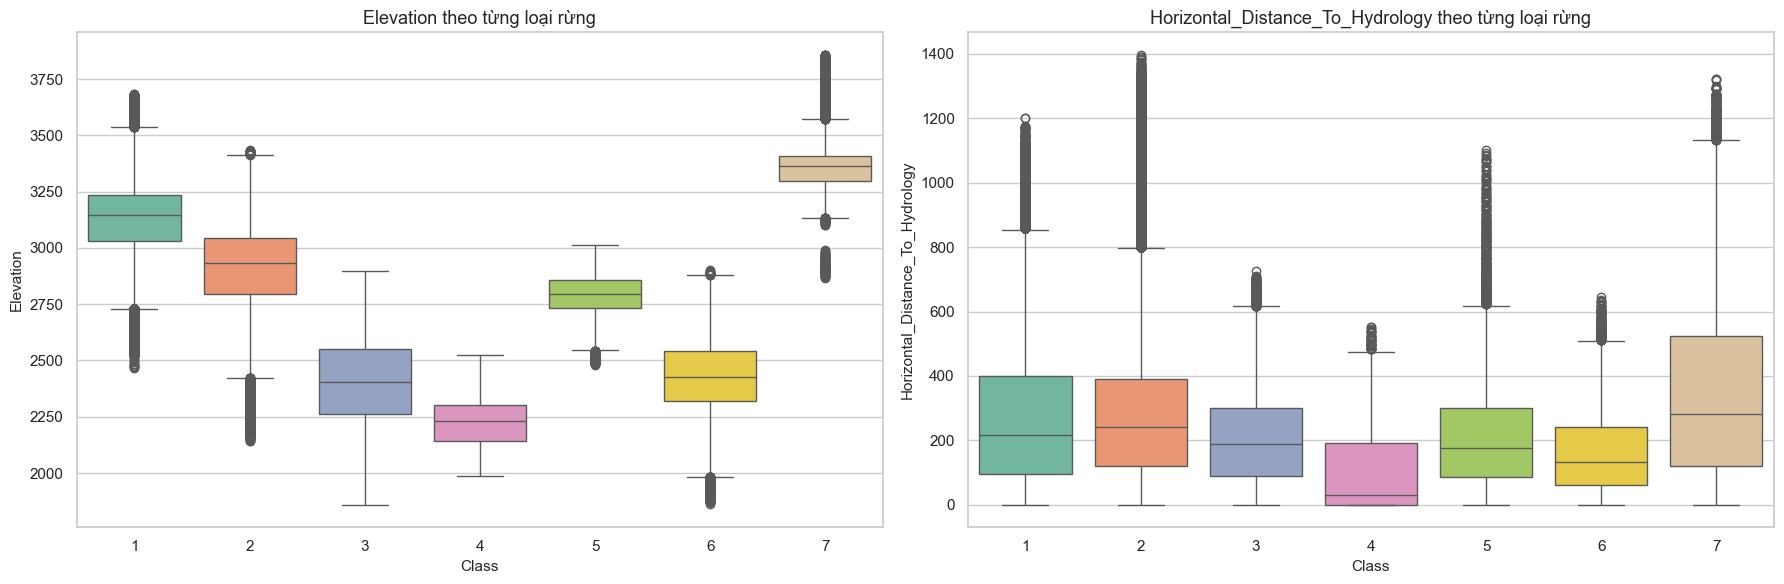

In [6]:

# Phân tích 3 - Boxplot theo lớp cho biến tiêu biểu


boxplot_features = ["Elevation", "Horizontal_Distance_To_Hydrology"]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for i, col in enumerate(boxplot_features):
    sns.boxplot(
        data=df,
        x=target_col,
        y=col,
        hue=target_col,
        order=order,
        dodge=False,
        palette="Set2",
        ax=axes[i],
    )
    if axes[i].legend_ is not None:
        axes[i].legend_.remove()
    axes[i].set_title(f"{col} theo từng loại rừng")
    axes[i].set_xlabel("Class")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

## Diễn giải 

Nhận xét từ boxplot:
- `Elevation` thể hiện mức phân tách lớp tương đối tốt: class 7 có cao độ cao nhất, class 4 thấp nhất.
- Các lớp 3, 4, 6 có vùng phân phối giao nhau đáng kể ở cao độ trung bình-thấp, nên dễ nhầm lẫn nếu chỉ dựa một biến.
- `Horizontal_Distance_To_Hydrology` có nhiều outlier và độ phân tán lớn giữa các lớp, nên có giá trị bổ trợ nhưng khó là biến quyết định độc lập.

## Phân tích 4: Tương quan giữa biến liên tục

Mục tiêu của phần này:
- Đo mức liên hệ tuyến tính giữa các biến continuous.
- Phát hiện các cụm biến có khả năng đa cộng tuyến.
- Xác định nhóm biến có thể chứa thông tin trùng lặp.

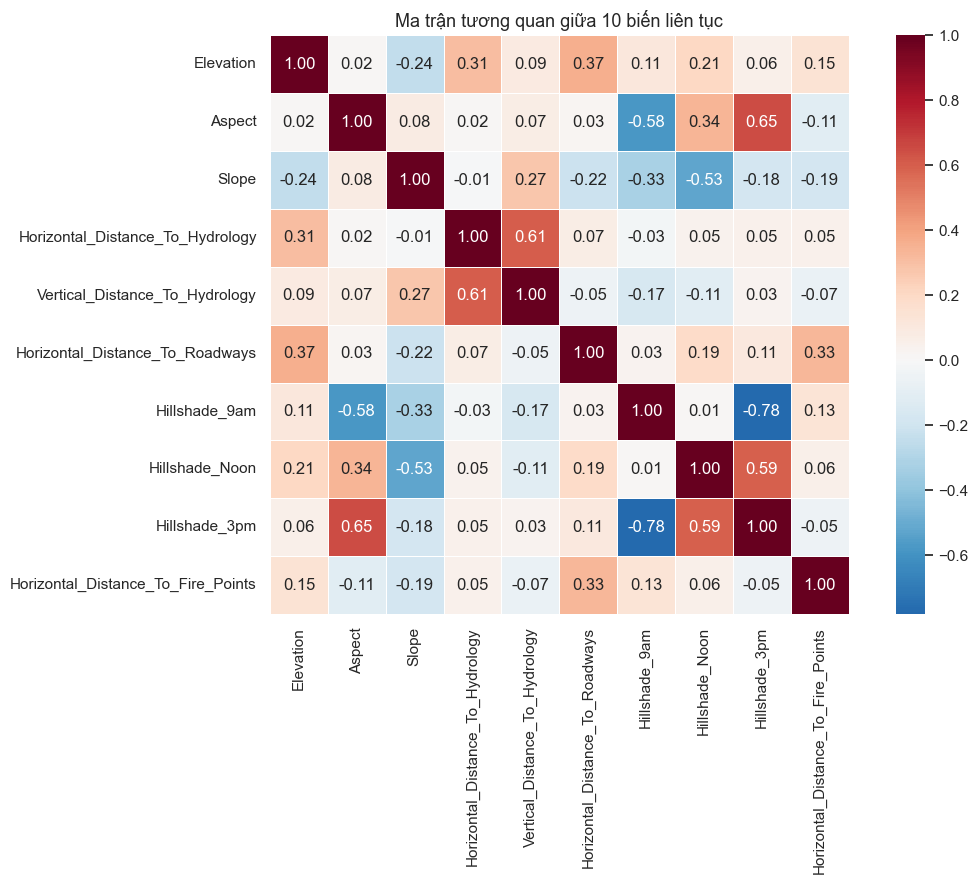

Top 8 cặp tương quan |corr| cao nhất:
Hillshade_9am                     Hillshade_3pm                      0.780296
Aspect                            Hillshade_3pm                      0.646944
Horizontal_Distance_To_Hydrology  Vertical_Distance_To_Hydrology     0.606236
Hillshade_Noon                    Hillshade_3pm                      0.594274
Aspect                            Hillshade_9am                      0.579273
Slope                             Hillshade_Noon                     0.526911
Elevation                         Horizontal_Distance_To_Roadways    0.365559
Aspect                            Hillshade_Noon                     0.336103
dtype: float64


In [7]:

# Phân tích 4 - Tương quan biến liên tục


corr_matrix = df[continuous_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    square=True,
)
plt.title("Ma trận tương quan giữa 10 biến liên tục")
plt.tight_layout()
plt.show()

# In top cặp tương quan tuyệt đối cao nhất (bỏ đường chéo)
corr_pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack()
print("Top 8 cặp tương quan |corr| cao nhất:")
print(corr_pairs.abs().sort_values(ascending=False).head(8))

## Diễn giải 

Các cặp có |corr| nổi bật nhất:
- `Hillshade_9am` - `Hillshade_3pm`: 0.780 (mạnh)
- `Aspect` - `Hillshade_3pm`: 0.647
- `Horizontal_Distance_To_Hydrology` - `Vertical_Distance_To_Hydrology`: 0.606
- `Hillshade_Noon` - `Hillshade_3pm`: 0.594

Diễn giải:
- Nhóm biến hillshade và aspect liên hệ chặt chẽ về mặt vật lý chiếu sáng địa hình.
- Có dấu hiệu đa cộng tuyến cục bộ trong một số cụm biến liên tục; cần lưu ý khi diễn giải hệ số mô hình tuyến tính.

## Phân tích 5: Vai trò của biến binary theo lớp

Mục tiêu của phần này:
- Đo tần suất xuất hiện của từng `Wilderness_Area` và `Soil_Type` trong mỗi lớp.
- Xác định đặc trưng binary nổi bật nhất theo class.
- Bổ sung góc nhìn sinh thái để hỗ trợ phân tách lớp.

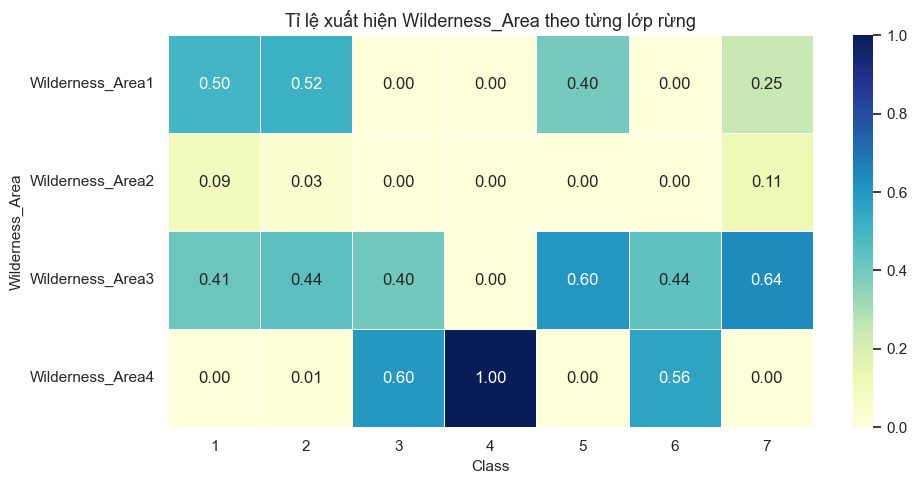

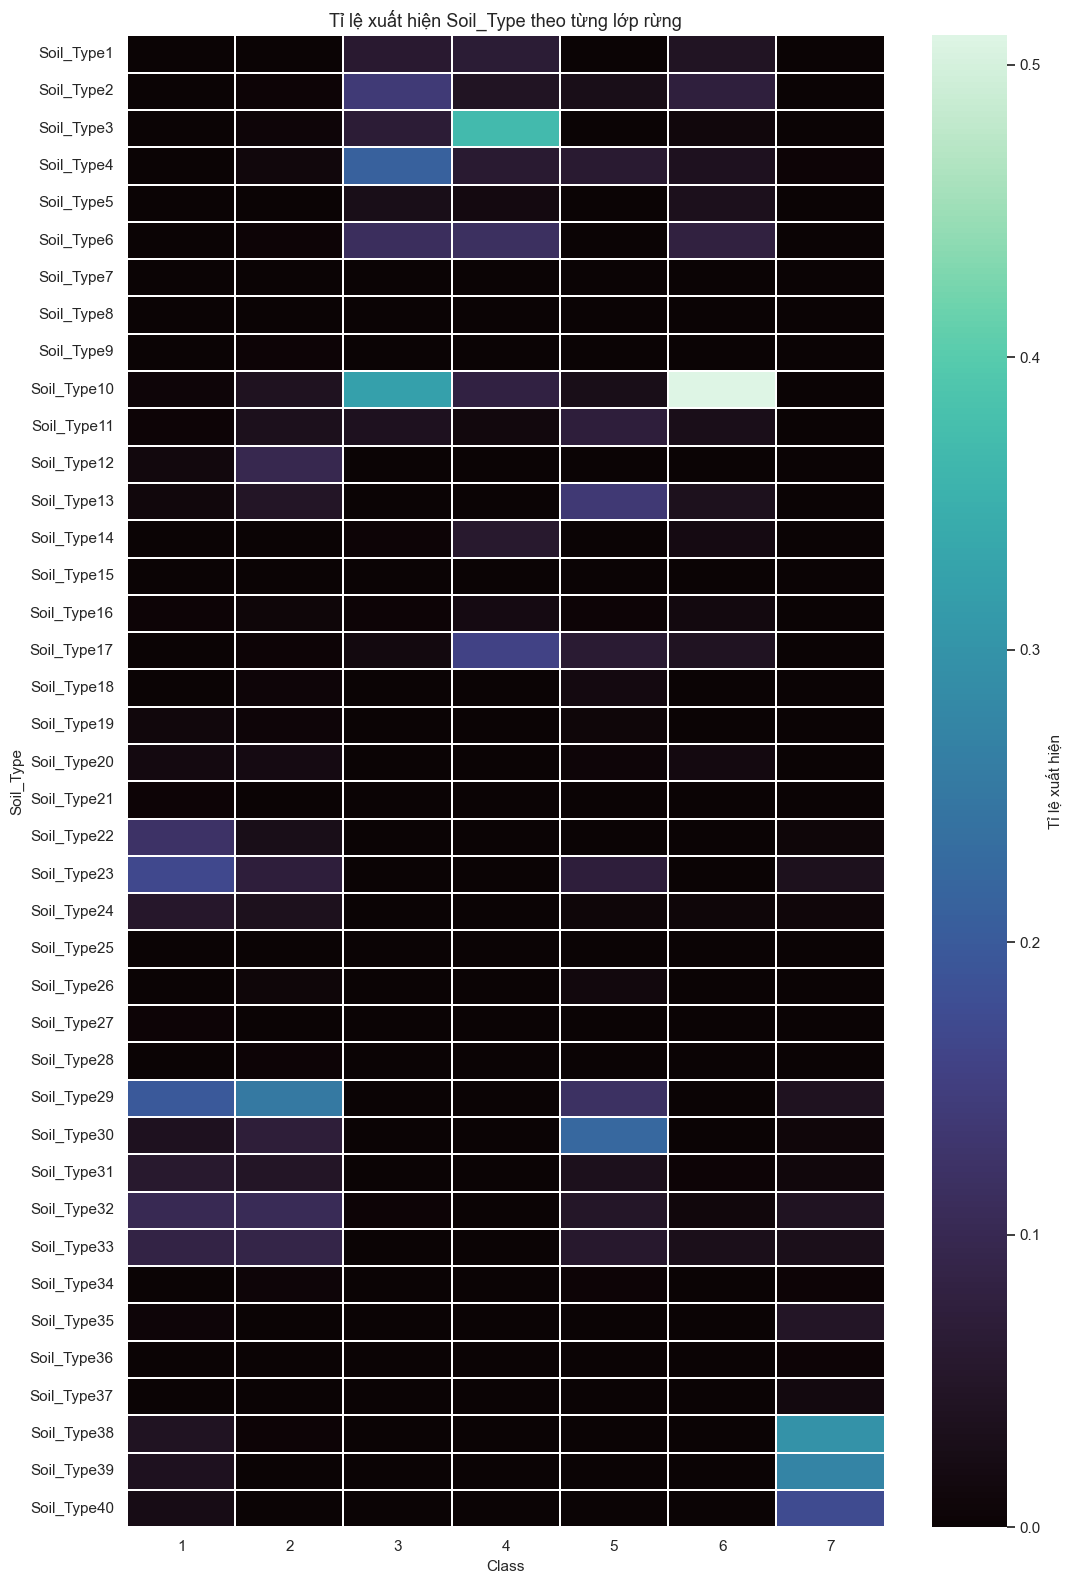

Đặc trưng binary nổi bật theo từng lớp rừng:
           Top_Wilderness_Area Top_Soil_Type  Top_Wilderness_Ratio  \
Cover_Type                                                           
1             Wilderness_Area1   Soil_Type29                 0.499   
2             Wilderness_Area1   Soil_Type29                 0.516   
3             Wilderness_Area4   Soil_Type10                 0.600   
4             Wilderness_Area4    Soil_Type3                 1.000   
5             Wilderness_Area3   Soil_Type30                 0.602   
6             Wilderness_Area4   Soil_Type10                 0.561   
7             Wilderness_Area3   Soil_Type38                 0.639   

            Top_Soil_Ratio  
Cover_Type                  
1                    0.198  
2                    0.252  
3                    0.323  
4                    0.371  
5                    0.222  
6                    0.510  
7                    0.298  


In [8]:

# Phân tích 5 - Biến binary (Wilderness, Soil)


wilderness_ratio_by_class = df.groupby(target_col)[wilderness_cols].mean()
soil_ratio_by_class = df.groupby(target_col)[soil_cols].mean()

plt.figure(figsize=(10, 5))
sns.heatmap(
    wilderness_ratio_by_class.T,
    cmap="YlGnBu",
    annot=True,
    fmt=".2f",
    linewidths=0.4,
)
plt.title("Tỉ lệ xuất hiện Wilderness_Area theo từng lớp rừng")
plt.xlabel("Class")
plt.ylabel("Wilderness_Area")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 16))
sns.heatmap(
    soil_ratio_by_class.T,
    cmap="mako",
    cbar_kws={"label": "Tỉ lệ xuất hiện"},
    linewidths=0.15,
)
plt.title("Tỉ lệ xuất hiện Soil_Type theo từng lớp rừng")
plt.xlabel("Class")
plt.ylabel("Soil_Type")
plt.tight_layout()
plt.show()

top_wilderness_each_class = wilderness_ratio_by_class.idxmax(axis=1)
top_soil_each_class = soil_ratio_by_class.idxmax(axis=1)

summary_table = pd.DataFrame(
    {
        "Top_Wilderness_Area": top_wilderness_each_class,
        "Top_Soil_Type": top_soil_each_class,
        "Top_Wilderness_Ratio": wilderness_ratio_by_class.max(axis=1).round(3),
        "Top_Soil_Ratio": soil_ratio_by_class.max(axis=1).round(3),
    }
)

print("Đặc trưng binary nổi bật theo từng lớp rừng:")
print(summary_table)

## Diễn giải 

Kết quả nổi bật:
- Class 4 gắn chặt với `Wilderness_Area4` (tỉ lệ 1.000).
- Class 6 nổi bật ở `Soil_Type10` với tỉ lệ 0.510.
- Class 1 và 2 cùng nổi bật ở `Soil_Type29`.
- Class 7 nổi bật ở `Soil_Type38`.

Diễn giải:
- Các biến one-hot Wilderness/Soil chứa tín hiệu phân lớp mạnh theo đặc trưng sinh thái vùng.
- Đây là nguồn thông tin quan trọng để giảm nhầm lẫn giữa các lớp có địa hình liên tục chồng lấn.

## Phân tích 6: Tương quan sơ bộ với biến mục tiêu

Mục tiêu của phần này:
- Xếp hạng nhanh mức liên hệ tuyến tính của từng biến continuous với Cover Type.
- Kiểm tra giả thuyết `Elevation` là biến quan trọng nhất ở mức sơ bộ.
- Tạo baseline insight trước khi đi vào feature importance từ mô hình.

Tương quan giữa biến liên tục và target (xếp theo |corr| giảm dần):
Elevation                            -0.269554
Horizontal_Distance_To_Roadways      -0.153450
Slope                                 0.148285
Horizontal_Distance_To_Fire_Points   -0.108936
Hillshade_Noon                       -0.096426
Vertical_Distance_To_Hydrology        0.081664
Hillshade_3pm                        -0.048290
Hillshade_9am                        -0.035415
Horizontal_Distance_To_Hydrology     -0.020317
Aspect                                0.017080
Name: Cover_Type, dtype: float64


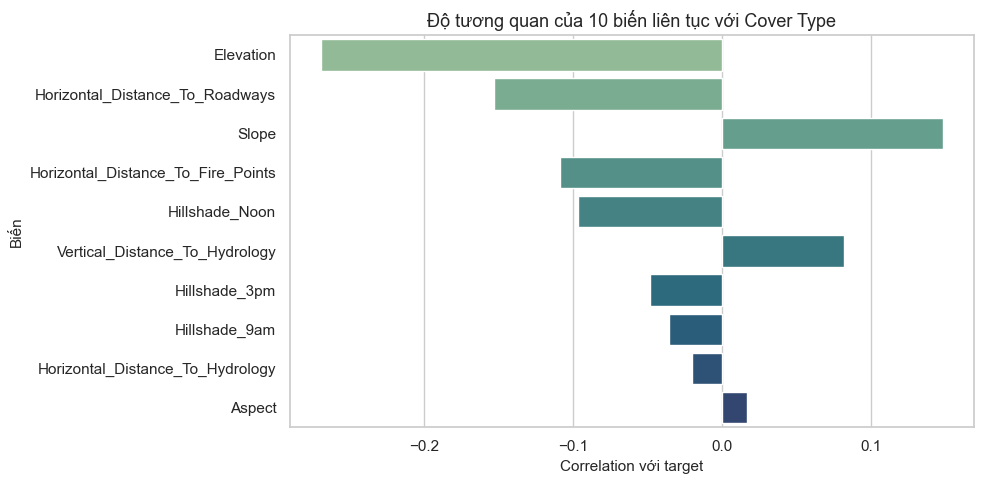

In [9]:

# Phân tích 6 - Tương quan sơ bộ với biến mục tiêu


corr_with_target = df[continuous_cols + [target_col]].corr()[target_col].drop(target_col)
corr_sorted = corr_with_target.reindex(corr_with_target.abs().sort_values(ascending=False).index)

print("Tương quan giữa biến liên tục và target (xếp theo |corr| giảm dần):")
print(corr_sorted)

plt.figure(figsize=(10, 5))
plot_df = corr_sorted.reset_index()
plot_df.columns = ["Feature", "Correlation"]
sns.barplot(data=plot_df, x="Correlation", y="Feature", hue="Feature", palette="crest", legend=False)
plt.title("Độ tương quan của 10 biến liên tục với Cover Type")
plt.xlabel("Correlation với target")
plt.ylabel("Biến")
plt.tight_layout()
plt.show()

## Phân tích 6B: Scatter matrix các biến quan trọng

Mục tiêu của phần này:
- Bổ sung phân tích quan hệ giữa các biến continuous quan trọng theo lớp.
- Quan sát trực tiếp vùng chồng lấn lớp trên không gian đặc trưng 2 chiều.
- Tạo cơ sở giải thích nhầm lẫn lớp trước khi huấn luyện mô hình classification.

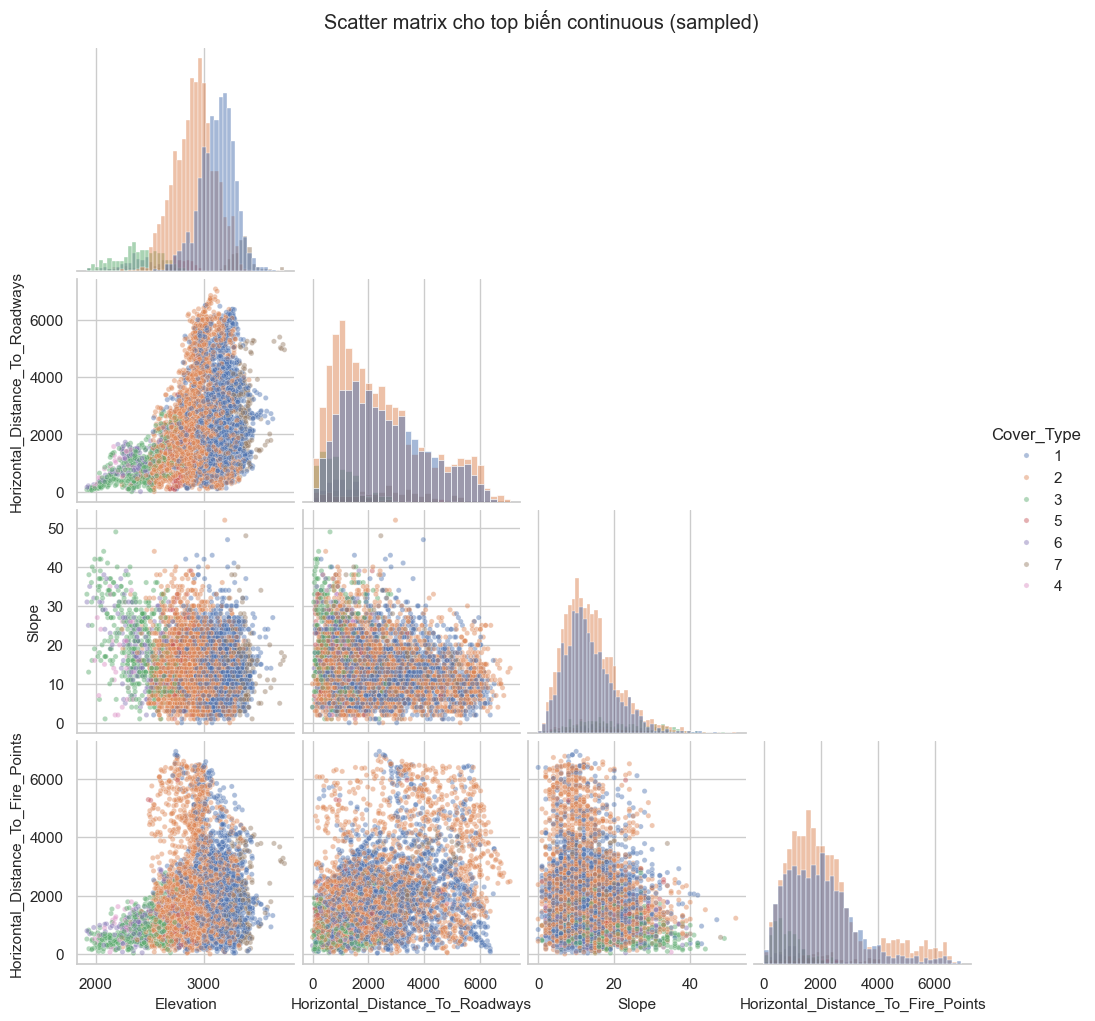

In [10]:
# Phân tích 6B - Scatter matrix cho nhóm biến quan trọng
top_scatter_features = corr_sorted.index[:4].tolist()

# Lấy mẫu con để pairplot chạy nhanh hơn trên dataset lớn
sample_size = min(6000, len(df))
scatter_sample = df.sample(n=sample_size, random_state=SEED)

pairplot_df = scatter_sample[top_scatter_features + [target_col]].copy()
pairplot_df[target_col] = pairplot_df[target_col].astype(str)

sns.pairplot(
    data=pairplot_df,
    vars=top_scatter_features,
    hue=target_col,
    diag_kind="hist",
    corner=True,
    plot_kws={"alpha": 0.45, "s": 14},
)
plt.suptitle("Scatter matrix cho top biến continuous (sampled)", y=1.02)
plt.show()

## Diễn giải scatter/pairplot

- Các cặp biến có cluster khác nhau theo lớp cho thấy thông tin tách lớp là đa chiều, không chỉ đến từ một biến riêng lẻ.
- Các vùng chồng lấn quan sát được là tín hiệu sớm cho các cặp lớp dễ nhầm lẫn trong confusion matrix.
- Dùng mẫu con giúp trực quan rõ mà vẫn giữ chi phí tính toán hợp lý trên dữ liệu lớn.

# Tổng hợp Insight Cuối Cùng

## 1) Biến có tín hiệu mạnh với target
- `Elevation` có tương quan tuyệt đối lớn nhất với Cover Type ($|corr| \approx 0.270$), xác nhận vai trò quan trọng của cao độ.
- Các biến tiếp theo như `Horizontal_Distance_To_Roadways` và `Slope` cũng có tín hiệu đáng kể nhưng yếu hơn.

## 2) Nguồn gây khó cho mô hình
- Mất cân bằng lớp rất mạnh (ratio 103.13).
- Có vùng chồng lấn trong boxplot giữa một số lớp ở nhóm cao độ trung bình-thấp.
- Một số cụm biến continuous tương quan cao, có thể gây trùng thông tin.

## 3) Định hướng modeling từ EDA
- Dùng metric theo lớp: macro-F1, balanced accuracy, per-class recall.
- Theo dõi ma trận nhầm lẫn để xác nhận các cặp lớp dễ lẫn.
- Khai thác đồng thời continuous + binary để tận dụng cả tín hiệu địa hình và vùng sinh thái.